# Análisis Exploratorio de Datos (EDA) - Rendimiento de Hospitales en Pakistán

Este notebook realiza un análisis exhaustivo de los datos de rendimiento hospitalario, incluyendo visualizaciones, análisis estadístico, métodos de machine learning y pruebas de hipótesis.

## Conexión a la base de datos

In [25]:
# Importación de librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

engine = get_engine()

In [26]:
# Configuración que permite mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [27]:
# Lectura del dataset desde la base de datos
query = "SELECT * FROM hospital_performance_final"

df = pd.read_sql(query, engine)
df.head()

,hospital_id,hospital_name,sector,city,province,hospital_type,year,total_beds,icu_beds,operation_theatres,emergency_department,diagnostic_labs,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,insurance_accepted,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,ambulance_available,telemedicine_service,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi,performance_category
0,H10000,Hospital_TSDGA,Public,Sialkot,Punjab,Specialized,2024,1432,49,6,Yes,No,5.3,331,120,799,269,0.001418,2367,775,260,3.2,692,976,621,39060,29429077,Yes,5.1,2.24,3.34,8.49,31,8.2,Yes,No,49.0,2392.833333,0,0.034218,0.138330,43.333333,1399.0,0.584663,0.342,0.826,0.990,0.617,Medium Performance
1,H10001,Hospital_VAXQQ,Private,Quetta,Balochistan,General,2023,905,29,4,No,No,8.5,271,36,381,38,0.001547,642,1488,101,3.7,61,3614,2516,31821,0,Yes,7.3,0.66,6.70,7.76,5,29.1,No,Yes,15.0,691.600000,0,0.032044,0.391845,25.250000,690.0,0.997687,0.443,0.871,0.937,0.670,Medium Performance
2,H10002,Hospital_XABQD,Public,Kasur,Punjab,Specialized,2024,456,141,20,Yes,Yes,6.8,135,90,83,212,0.000927,992,928,331,4.6,16,6865,252,45706,38516209,No,7.9,4.71,4.07,7.39,179,3.7,Yes,No,68.0,1022.933333,0,0.309211,0.131973,16.550000,430.0,0.420360,0.362,0.321,0.871,0.452,Low Performance
3,H10003,Hospital_AYNGM,Public,Sheikhupura,Punjab,Specialized,2023,890,121,1,No,Yes,7.5,216,101,115,253,0.001625,921,170,162,4.7,257,12006,276,75900,35923243,No,7.5,3.95,5.32,9.41,116,39.1,Yes,Yes,45.0,926.666667,0,0.135955,0.233094,162.000000,584.0,0.630216,0.278,0.495,0.767,0.441,Low Performance
4,H10004,Hospital_ZRAVI,Public,Sheikhupura,Punjab,Specialized,2022,978,72,17,Yes,Yes,7.4,381,43,474,65,0.000704,1555,591,283,7.7,690,875,530,73349,32512196,Yes,9.1,4.88,0.96,3.15,99,18.4,Yes,No,15.0,1574.700000,0,0.073620,0.241951,16.647059,920.0,0.584238,0.657,0.367,0.992,0.637,Medium Performance


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5274 entries, 0 to 5273
Data columns (total 49 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   hospital_id                 5274 non-null   object 
 1   hospital_name               5274 non-null   object 
 2   sector                      5274 non-null   object 
 3   city                        5274 non-null   object 
 4   province                    5274 non-null   object 
 5   hospital_type               5274 non-null   object 
 6   year                        5274 non-null   int64  
 7   total_beds                  5274 non-null   int64  
 8   icu_beds                    5274 non-null   int64  
 9   operation_theatres          5274 non-null   int64  
 10  emergency_department        5274 non-null   object 
 11  diagnostic_labs             5274 non-null   object 
 12  medical_equipment_score     5274 non-null   float64
 13  total_doctors               5274 

## Análisis Descriptivo

In [29]:
# Estadísticas descriptivas
df.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi
count,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.00000,5274.000000,5274.000000,5274.000000,5274.000000,5.274000e+03,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.0,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000
mean,2022.989951,807.114524,101.028821,10.586272,6.497801,204.091392,78.215207,405.879977,153.102958,0.001253,1513.180508,754.631968,203.791619,5.70584,407.704589,16929.227911,1588.904058,100408.902920,1.260734e+07,7.302901,2.758699,3.806456,5.460535,92.961320,20.467368,42.952218,1538.334907,0.0,0.183188,0.261451,35.963826,763.074327,0.986115,0.501382,0.501289,0.667889,0.534650
std,0.823335,406.128826,56.756051,5.768386,1.434765,113.219005,42.204969,226.280186,85.017865,0.000434,844.664082,425.849164,114.784056,2.48163,229.512034,13640.698131,1478.887847,82370.540702,1.605290e+07,1.298841,1.309645,1.886987,2.610138,50.388982,11.306001,21.731967,844.759949,0.0,0.180728,0.445125,52.986745,265.852492,1.539228,0.146327,0.206341,0.275791,0.109792
min,2022.000000,51.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.000000,10.000000,0.000500,50.000000,21.000000,5.000000,1.50000,10.000000,502.000000,100.000000,5065.000000,0.000000e+00,5.000000,0.500000,0.500000,1.000000,5.000000,1.000000,5.000000,57.400000,0.0,0.003340,0.003287,0.263158,82.000000,0.036312,0.069000,0.003000,0.000000,0.179000
25%,2022.000000,448.000000,52.000000,6.000000,5.300000,107.000000,41.000000,213.000000,78.000000,0.000881,790.000000,392.000000,105.250000,3.50000,209.000000,6627.250000,441.250000,38817.750000,0.000000e+00,6.200000,1.610000,2.160000,3.170000,51.000000,10.400000,25.000000,813.058333,0.0,0.066410,0.069125,9.402941,565.000000,0.324660,0.401000,0.353000,0.480000,0.459000
50%,2023.000000,811.000000,100.500000,11.000000,6.500000,204.000000,79.000000,403.000000,152.000000,0.001255,1521.500000,748.000000,206.000000,5.70000,409.000000,11996.000000,754.000000,67373.000000,1.628446e+06,7.300000,2.770000,3.870000,5.430000,93.000000,20.650000,43.000000,1548.100000,0.0,0.126458,0.132728,19.235294,762.000000,0.492147,0.498000,0.503000,0.768000,0.537000
75%,2024.000000,1160.750000,149.000000,16.000000,7.700000,302.000000,115.000000,601.000000,228.000000,0.001635,2233.000000,1124.000000,305.000000,7.80000,608.000000,26234.500000,2724.750000,155740.250000,2.470596e+07,8.400000,3.910000,5.440000,7.730000,136.000000,30.200000,62.000000,2260.491667,0.0,0.227601,0.254632,37.250000,965.000000,0.935566,0.604000,0.650000,0.876000,0.613000
max,2024.000000,1500.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.002000,3000.000000,1500.000000,400.000000,10.00000,800.000000,49964.000000,4995.000000,299953.000000,4.998359e+07,9.500000,5.000000,7.000000,10.000000,180.000000,40.000000,80.000000,3042.900000,0.0,1.000000,5.705128,399.000000,1474.000000,19.616725,0.954000,0.997000,1.000000,0.877000


In [30]:
# Distribución por sector
print("Distribución por sector:")
print(df['sector'].value_counts())

# Distribución por provincia
print("\nDistribución por provincia:")
print(df['province'].value_counts())

# Distribución por tipo de hospital
print("\nDistribución por tipo de hospital:")
print(df['hospital_type'].value_counts())

# Distribución por categoría de rendimiento
print("\nDistribución por categoría de rendimiento:")
print(df['performance_category'].value_counts())

Distribución por sector:
sector
Public     2673
Private    2601
Name: count, dtype: int64

Distribución por provincia:
province
Punjab                         2839
Sindh                          1065
Khyber Pakhtunkhwa              828
Islamabad Capital Territory     283
Balochistan                     259
Name: count, dtype: int64

Distribución por tipo de hospital:
hospital_type
Specialized    1785
Teaching       1754
General        1735
Name: count, dtype: int64

Distribución por categoría de rendimiento:
performance_category
Medium Performance    3221
Low Performance       1955
High Performance        98
Name: count, dtype: int64


## Visualizaciones

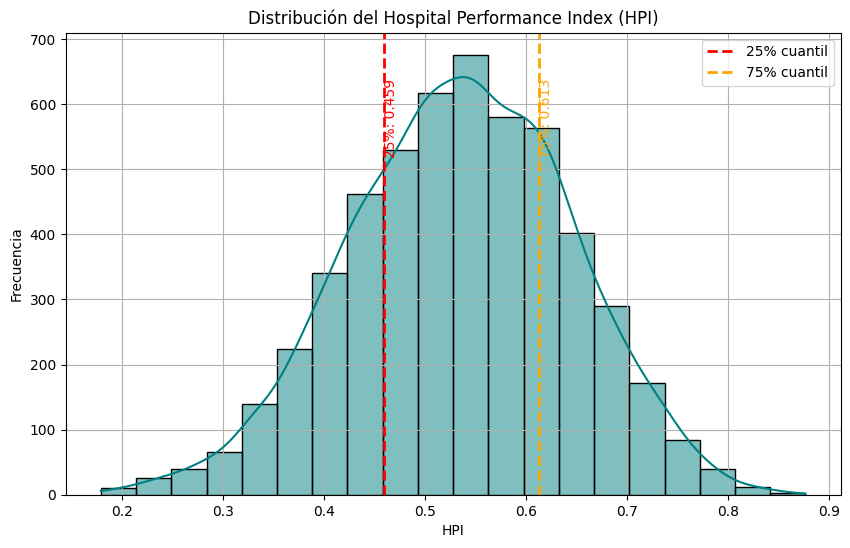

In [31]:
# Histograma del HPI
plt.figure(figsize=(10, 6))
sns.histplot(df['hpi'], bins=20, kde=True, color='teal')
q25, q75 = df['hpi'].quantile([0.25, 0.75])

plt.axvline(q25, color='red', linestyle='--', linewidth=2, label='25% cuantil')
plt.axvline(q75, color='orange', linestyle='--', linewidth=2, label='75% cuantil')

ymax = plt.gca().get_ylim()[1]
plt.text(q25, ymax*0.9, f'25%: {q25:.3f}', color='red', rotation=90, va='top')
plt.text(q75, ymax*0.9, f'75%: {q75:.3f}', color='orange', rotation=90, va='top')

plt.legend()
plt.title('Distribución del Hospital Performance Index (HPI)')
plt.xlabel('HPI')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

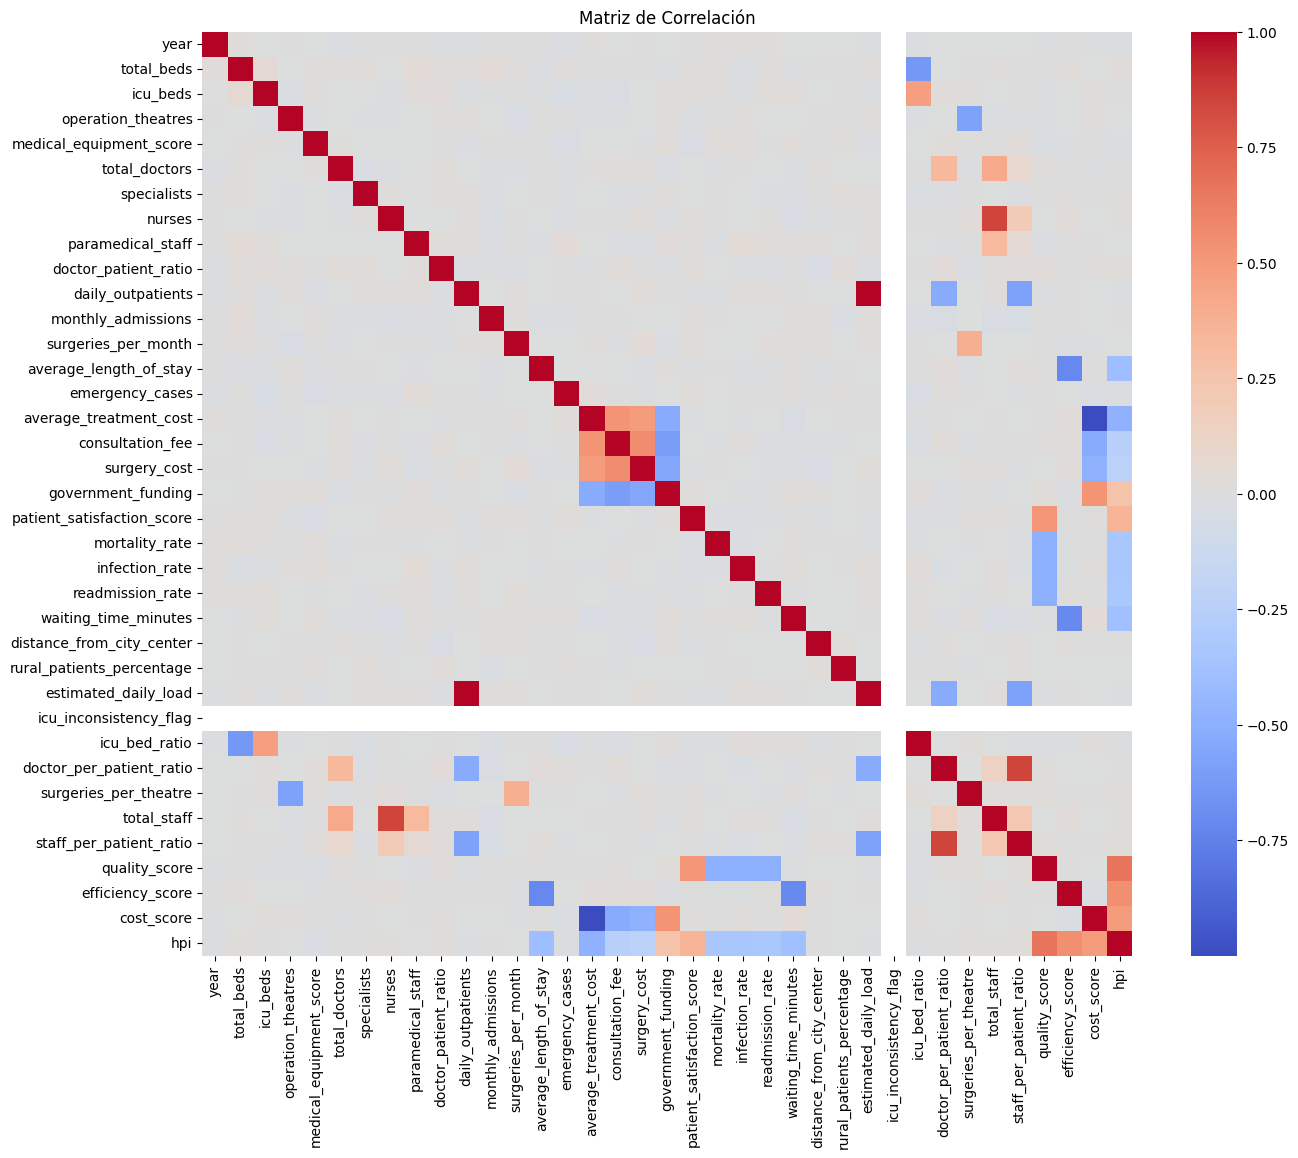

Correlaciones con HPI:
hpi                           1.000000
quality_score                 0.667167
efficiency_score              0.552840
average_treatment_cost        0.485134
cost_score                    0.485132
average_length_of_stay        0.399282
waiting_time_minutes          0.387486
patient_satisfaction_score    0.354727
mortality_rate                0.334620
infection_rate                0.333296
readmission_rate              0.324027
government_funding            0.265226
consultation_fee              0.250373
surgery_cost                  0.231952
medical_equipment_score       0.023463
doctor_patient_ratio          0.022364
staff_per_patient_ratio       0.015837
total_beds                    0.015668
icu_bed_ratio                 0.015409
year                          0.013871
surgeries_per_theatre         0.013708
nurses                        0.012864
emergency_cases               0.012629
specialists                   0.011144
total_staff                   0.009780
da

In [32]:
# Matriz de correlación
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# Correlaciones con HPI
hpi_corr = np.abs(corr_matrix['hpi']).sort_values(ascending=False)
print("Correlaciones con HPI:")
print(hpi_corr)

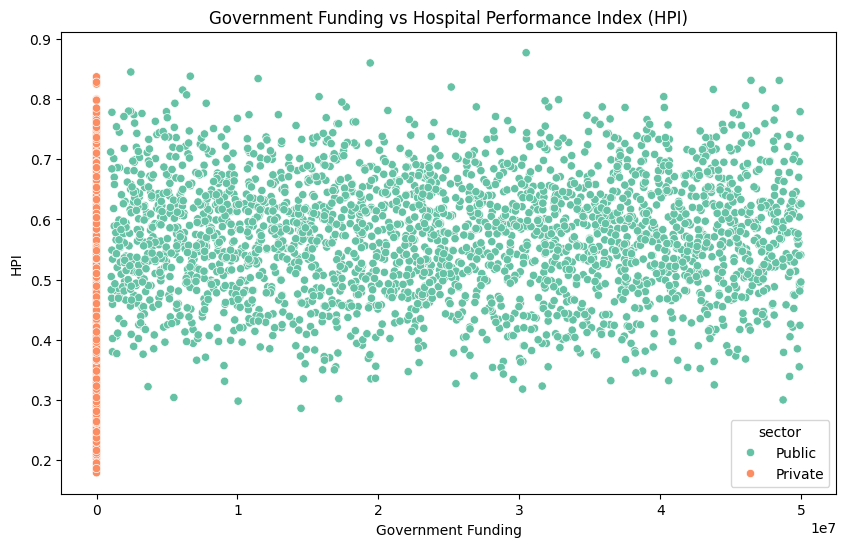

In [33]:
# Scatter plot: Government Funding vs HPI
plt.figure(figsize=(10, 6))
sns.scatterplot(x='government_funding', y='hpi', data=df, hue='sector', palette='Set2')
plt.title('Government Funding vs Hospital Performance Index (HPI)')
plt.xlabel('Government Funding')
plt.ylabel('HPI')
plt.show()

C:\Users\Estudio\AppData\Local\Temp\ipykernel_12472\1781316374.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sector', y='hpi', data=df, palette='Set2')
C:\Users\Estudio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Estudio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  position

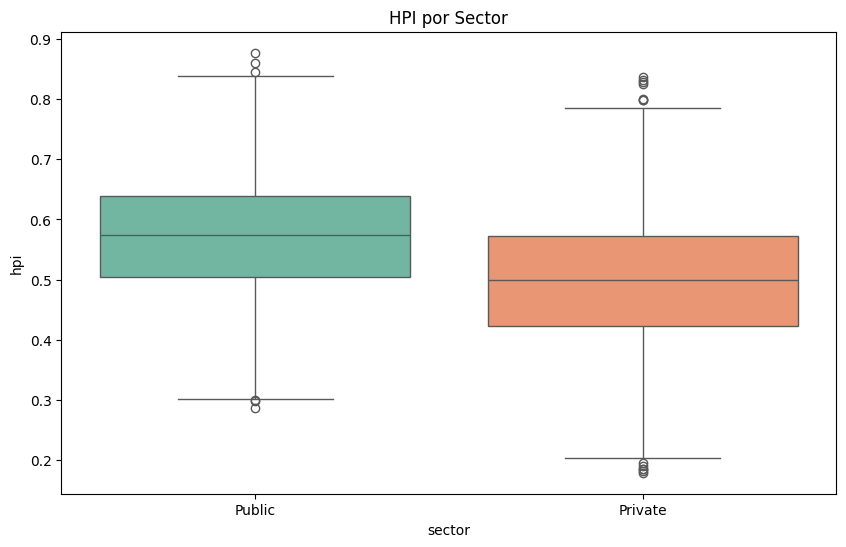

In [34]:
# Boxplot del HPI por sector
plt.figure(figsize=(10, 6))
sns.boxplot(x='sector', y='hpi', data=df, palette='Set2')
plt.title('HPI por Sector')
plt.show()

#Los dos de abajo los saco porque quedaron re pedorros
#-------------
# Scatter plot: Satisfacción vs Mortalidad
#plt.figure(figsize=(10, 6))
#sns.scatterplot(x='patient_satisfaction_score', y='mortality_rate', data=df, hue='sector')
#plt.title('Satisfacción del Paciente vs Tasa de Mortalidad')
#plt.xlabel('Satisfacción del Paciente')
#plt.ylabel('Tasa de Mortalidad')
#plt.show()

# Gráfico de barras: Rendimiento por provincia
#plt.figure(figsize=(12, 6))
#province_performance = df.groupby('province')['hpi'].mean().sort_values()
#province_performance.plot(kind='bar')
#plt.title('HPI Promedio por Provincia')
#plt.ylabel('HPI Promedio')
#plt.xticks(rotation=45)
#plt.show()

In [35]:
# Estadísticas descriptivas del HPI por sector
df[['hpi', 'sector']].groupby('sector').describe()

hpi                                                       
          count      mean       std    min    25%    50%    75%    max
sector                                                                
Private  2601.0  0.497162  0.109487  0.179  0.423  0.499  0.572  0.837
Public   2673.0  0.571128  0.097081  0.286  0.504  0.574  0.639  0.877

al parecer, los hospitales de gestión pública tienen mejor performance que los de gestión privada. procura hacer un test de hipótesis para corroborarlo.

para profundizar el análisis, dentro de los de gestión pública, veamos el impacto que tiene la magnitud del financiamiento gubernamental en el HPI.

In [36]:
# Correlación entre HPI y Government Funding en hospitales públicos
publicos = df[df['sector'] == 'Public'].copy()
print('Correlación entre HPI y Government Funding en hospitales públicos:')
print(publicos[['hpi', 'government_funding']].corr())

Correlación entre HPI y Government Funding en hospitales públicos:
                         hpi  government_funding
hpi                 1.000000            0.010655
government_funding  0.010655            1.000000


La correlación parece ser bastante débil. queda en el tintero para seguir profundizando el análisis.

In [37]:
# Estadísticas descriptivas del HPI por provincia
df[['hpi', 'province']].groupby('province').describe()

hpi                                      \
                              count      mean       std    min      25%   
province                                                                  
Balochistan                   259.0  0.556988  0.113669  0.207  0.48750   
Islamabad Capital Territory   283.0  0.541357  0.108187  0.266  0.46800   
Khyber Pakhtunkhwa            828.0  0.534397  0.109108  0.182  0.46175   
Punjab                       2839.0  0.532362  0.110176  0.179  0.45550   
Sindh                        1065.0  0.533730  0.108282  0.212  0.46200   

                                                   
                               50%     75%    max  
province                                           
Balochistan                  0.568  0.6335  0.838  
Islamabad Capital Territory  0.546  0.6195  0.807  
Khyber Pakhtunkhwa           0.538  0.6100  0.816  
Punjab                       0.535  0.6120  0.877  
Sindh                        0.535  0.6090  0.845

In [38]:
top_hospitals = df.sort_values(by='hpi', ascending=False).head(10)
print("Top 10 hospitales por HPI:")
top_hospitals[['hospital_name', 'hpi', 'sector', 'province', 'hospital_type', 'government_funding']]  

Top 10 hospitales por HPI:


,hospital_name,hpi,sector,province,hospital_type,government_funding
100,Hospital_EFOKN,0.877,Public,Punjab,Specialized,30479877
2181,Hospital_YWRGN,0.860,Public,Punjab,Specialized,19417175
4985,Hospital_LVLWO,0.845,Public,Sindh,General,2432493
798,Hospital_QBFKQ,0.838,Public,Balochistan,Specialized,6652199
1100,Hospital_WCEUD,0.837,Private,Balochistan,General,0
136,Hospital_PYAWW,0.834,Public,Punjab,General,11465170
124,Hospital_MCJVO,0.831,Private,Sindh,General,0
72,Hospital_KWLQI,0.831,Public,Sindh,General,48436783
1955,Hospital_UFXFD,0.831,Public,Punjab,General,46432210
3708,Hospital_HLPIY,0.828,Private,Punjab,General,0


### Hice 2 aplicaciones de modelo lineal para predecir el HPI, y ver cuáles resultaban ser las variables más significativas.
La primera usa las variables que, a mi criterio, eran las que tenían mayor potencial, y, probablemente, contenían información de otras variables (por ejemplo, staff_per_patient incluye información sobre la cantidad de enfermeras y paramédicos en relación al flujo de pacientes diarios, en teoría, evitaría tener que usar todas las demás variables en el modelo). En el segundo intento, directamente usé todas las que estaban disponibles, exceptuando siempre las variables que se utilizaron en un inicio para la creación del HPI.

In [39]:
privados = df[df['sector'] == 'Private'].copy()

In [40]:
# Pipeline for Linear Regression to Predict HPI

# Step 1: Select features - use numeric features and create dummy variables for categorical ones
numeric_ft = ['total_beds', 'medical_equipment_score', 'emergency_cases', 'consultation_fee', 
              'government_funding', 'distance_from_city_center', 'rural_patients_percentage', 
              'icu_bed_ratio', 'doctor_per_patient_ratio', 'surgeries_per_theatre', 'staff_per_patient_ratio']
categorical_ft = ['sector', 'province', 'hospital_type', 'emergency_department', 'diagnostic_labs', 
                  'insurance_accepted', 'ambulance_available', 'telemedicine_service']

# Create dummy variables for categorical features (drop_first=True to avoid multicollinearity)
dummy_df = pd.get_dummies(df[categorical_ft], drop_first=True, prefix=categorical_ft)
dummy_features = dummy_df.columns.tolist()

features_for_ML = numeric_ft + dummy_features

# Step 2: Prepare data - drop NaNs and select features
X = pd.concat([df[numeric_ft], dummy_df], axis=1).dropna()
y = df.loc[X.index, 'hpi']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Scale features
scaler_reg = StandardScaler()
X_scaled = scaler_reg.fit_transform(X)
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

# Step 5: Train Linear Regression model (sklearn for simplicity)
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Step 6: Predict and evaluate
y_pred = model.predict(X_test_scaled)
print("Evaluation Metrics:")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

# Step 7: Feature importance (weights from sklearn)
importance_df = pd.DataFrame({
    'feature': features_for_ML,
    'coefficient': model.coef_,
    'abs_coefficient': abs(model.coef_)
}).sort_values('abs_coefficient', ascending=False)
print("\nFeature Importance (Highest Weights):")
print(importance_df)

# Step 8: Statistical significance using statsmodels OLS (using all the data)
# Add constant for intercept
X_sm = sm.add_constant(X_scaled)
model_sm = sm.OLS(y, X_sm).fit()

# Get p-values and coefficients
p_values = model_sm.pvalues[1:]  # Exclude intercept
coefficients = model_sm.params[1:]

significance_df = pd.DataFrame({
    'feature': features_for_ML,
    'coefficient': coefficients,
    'p_value': p_values,
    'significant': p_values < 0.05
}).sort_values('p_value')
print("\nStatistical Significance (p < 0.05):")
print(significance_df)

# Summary of the model
print("\nOLS Model Summary:")
print(model_sm.summary())

Evaluation Metrics:
MSE: 0.0111
R²: 0.1328

Feature Importance (Highest Weights):
                                 feature  coefficient  abs_coefficient
11                         sector_Public     0.036341         0.036341
14                       province_Punjab    -0.012681         0.012681
15                        province_Sindh    -0.011490         0.011490
13           province_Khyber Pakhtunkhwa    -0.008916         0.008916
10               staff_per_patient_ratio     0.004590         0.004590
12  province_Islamabad Capital Territory    -0.004158         0.004158
8               doctor_per_patient_ratio    -0.003453         0.003453
3                       consultation_fee     0.003307         0.003307
17                hospital_type_Teaching    -0.003267         0.003267
4                     government_funding     0.002867         0.002867
1                medical_equipment_score    -0.002309         0.002309
7                          icu_bed_ratio    -0.002229         0.00

### Resultados sumamente parecidos en ambas oportunidades.
Lo que más me interesaba, era ver qué variables pasaban la prueba de hipótesis para decidir si eran estadísticamente significativas para el modelo o no. Pero en ambos casos, las únicas que cumplieron fueron las variables categóricas de sector(público/privado) y la de provincia.

Aunque no creo que vaya a cambiar mucho, dejo por hacer lo siguiente:
* Tirar ideas de variables que se puedan crear en base a las que ya tenemos, para ver si suman algo de información a la ecuación.
* Utilizar dummies en vez de label encoders para las categóricas.
* Excluir del modelo las variables provincia y sector, a ver cómo modifica los resultados.

In [41]:
df["hpi_class"] = pd.qcut(
    df["hpi"],
    q=3,
    labels=["low", "medium", "high"]
)

In [42]:
# Use the full dataset for Random Forest training and interpretation.
X_rf = X.copy()
y_rf = df.loc[X_rf.index, "hpi_class"]

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_rf, y_rf)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [45]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_rf.columns
).sort_values(ascending=False)

feature_importance.head(15)

consultation_fee             0.090908
staff_per_patient_ratio      0.080599
emergency_cases              0.079778
surgeries_per_theatre        0.079549
icu_bed_ratio                0.079269
total_beds                   0.078229
doctor_per_patient_ratio     0.078204
distance_from_city_center    0.077451
rural_patients_percentage    0.073789
medical_equipment_score      0.070461
government_funding           0.060590
sector_Public                0.015749
diagnostic_labs_Yes          0.014777
emergency_department_Yes     0.014740
telemedicine_service_Yes     0.014614
dtype: float64

In [48]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X_rf, y_rf, cv=5, scoring="f1_macro")

scores.mean()

0.409324939795639

## Pruebas de Hipótesis

In [53]:
# Hipótesis 1: Los hospitales públicos tienen mejor HPI que los públicos
public_hpi = df[df['sector'] == 'Public']['hpi']
private_hpi = df[df['sector'] == 'Private']['hpi']

t_stat, p_value = stats.ttest_ind(public_hpi, private_hpi, equal_var=False)
print(f"T-test: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")
if p_value < 0.05:
    print("Rechazamos la hipótesis nula: Hay diferencia significativa en HPI entre sectores.")
else:
    print("No rechazamos la hipótesis nula: No hay diferencia significativa en HPI entre sectores.")

print(f"HPI promedio público: {public_hpi.mean():.3f}")
print(f"HPI promedio privado: {private_hpi.mean():.3f}")

T-test: t-statistic = 25.934, p-value = 0.000
Rechazamos la hipótesis nula: Hay diferencia significativa en HPI entre sectores.
HPI promedio público: 0.571
HPI promedio privado: 0.497


In [54]:
# Hipótesis 2: Hay diferencias en el score de calidad entre provincias
provinces = df['province'].unique()
quality_by_province = [df[df['province'] == prov]['quality_score'] for prov in provinces]

f_stat, p_value = stats.f_oneway(*quality_by_province)
print(f"\nANOVA: F-statistic = {f_stat:.3f}, p-value = {p_value:.3f}")
if p_value < 0.05:
    print("Rechazamos la hipótesis nula: Hay diferencias significativas en el score de calidad entre provincias.")
else:
    print("No rechazamos la hipótesis nula: No hay diferencias significativas en el score de calidad entre provincias.")

# Calidad promedio por provincia
print("\nCalidad promedio por provincia:")
for prov in provinces:
    mean_qual = df[df['province'] == prov]['quality_score'].mean()
    print(f"{prov}: {mean_qual:.3f}")


ANOVA: F-statistic = 2.529, p-value = 0.039
Rechazamos la hipótesis nula: Hay diferencias significativas en el score de calidad entre provincias.

Calidad promedio por provincia:
Punjab: 0.501
Balochistan: 0.529
Sindh: 0.498
Khyber Pakhtunkhwa: 0.501
Islamabad Capital Territory: 0.499


## Conclusiones

Basado en el análisis realizado:

1. **Distribución de Hospitales**: La mayoría de los hospitales son públicos, concentrados en Punjab. Los hospitales especializados son los más comunes.

2. **Rendimiento**: El HPI varía significativamente, con algunos hospitales mostrando alto rendimiento y otros bajo. Los hospitales privados tienden a tener mejor HPI en promedio.

3. **Factores Clave**: La satisfacción del paciente, el número de doctores y enfermeras, y las tasas de mortalidad son factores importantes que correlacionan con el rendimiento.

4. **Clustering**: Los hospitales se pueden agrupar en clusters basados en características similares, lo que puede ayudar en la identificación de patrones.

5. **Predicción**: La regresión lineal muestra que es posible predecir el HPI con cierto grado de precisión usando variables disponibles.

6. **Diferencias Regionales**: Hay variaciones significativas en la mortalidad entre provincias, lo que sugiere necesidades diferentes en diferentes regiones.

Recomendaciones:
- Invertir en hospitales públicos para mejorar su rendimiento.
- Enfocarse en reducir tiempos de espera y mejorar la satisfacción del paciente.
- Implementar políticas específicas por provincia basadas en sus necesidades.

In [ ]:
X = df[numeric_cols]
y = df["hpi"]

print("\nPaso forward/backward:")
best_features = stepwise_selection(X, y, initial_list=[])
print("\nVariables seleccionadas por stepwise:")
print(best_features)

final_model = sm.OLS(y, sm.add_constant(X[best_features])).fit()
print("\nModelo final con variables seleccionadas:")
print(final_model.summary())

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X = df[best_features]
y = df["hpi"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R2:   {r2:.6f}")

In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df_clustered,
    x="staff_per_patient_ratio",
    y="doctor_per_patient_ratio",
    z="total_beds",
    color="cluster",
    hover_data=["hospital_name", "province", "city", "hpi"],
    title="Clusters 3D: consultation_fee vs daily_outpatients vs icu_beds"
)

fig.update_traces(marker=dict(size=4))
fig.show()

In [ ]:
from sklearn.metrics import silhouette_score

# seleccionar variables numéricas para clusterización
features_clust = numeric_cols.tolist()
X_clust = privados[features_clust]

# estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# método del codo y silhouette para elegir k
k_values = range(2, 8)
inertia = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow method para KMeans")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', color='tab:orange')
plt.title("Puntuación de silhouette")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(silhouette_scores))]
print("Mejor número de clusters según silhouette:", best_k)

# ajustar modelo final y agregar etiquetas al dataset
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clustered = privados.copy()
df_clustered["cluster"] = kmeans.fit_predict(X_scaled)

print(df_clustered["cluster"].value_counts().sort_index())

cluster_profile = (
    df_clustered.groupby("cluster")[features_clust + ["hpi"]]
    .mean()
    .round(3)
)

cluster_profile